# Skenario 4 — Primary Data Training

**Tujuan:** Melatih model terbaik hasil Skenario 3 menggunakan data primer yang telah dilabeli, kemudian mengevaluasi performanya pada data sekunder.

**Task:** Klasifikasi Emosi (5 kelas) dan Sentimen (3 kelas)

---

**Strategi:** Menggunakan model dan hyperparameter terbaik dari Skenario 3 untuk masing-masing task:
- **Emotion:** Learning Rate = 5e-5
- **Sentiment:** Epoch = 10

Data primer digunakan sebagai **training set** (dengan sebagian kecil sebagai validation set), sedangkan seluruh data sekunder digunakan sebagai **test set**.

**🏆 Output:** Model + tokenizer hasil pelatihan disimpan ke:
- `/kaggle/working/best_model_s4_Emotion/`
- `/kaggle/working/best_model_s4_Sentiment/`

Seluruh hasil evaluasi disimpan ke `results_s4.json`.

## 0. Install & Import

In [1]:
import subprocess, sys

def pip(*pkgs):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *pkgs])

pip("transformers[torch]", "datasets", "accelerate", "scikit-learn",
    "imbalanced-learn", "seaborn", "matplotlib",
    "pandas", "numpy", "torch")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 95.9 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cudf-cu12 26.2.1 requires numba-cuda[cu12]<0.23.0,>=0.22.2, but you hav

In [2]:
import os, re, json, warnings, random, time, gc
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer,
    EarlyStoppingCallback,
)
from datasets import Dataset as HFDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, f1_score,
    accuracy_score, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {DEVICE}")
print(f"PyTorch: {torch.__version__}")

Device : cuda
PyTorch: 2.10.0+cu128


## 1. Load & Preprocessing Dataset

In [3]:
PRIMARY_PATH = "/kaggle/input/datasets/carameyyow/primary-labeled/data_primer_labeled_best_model.csv"
SECONDARY_PATH = "/kaggle/input/datasets/carameyyow/secondary/PRDECT-ID Dataset_clean.csv"

df_primary = pd.read_csv(PRIMARY_PATH)
df_secondary = pd.read_csv(SECONDARY_PATH)

In [4]:
def clean_text(text):
    text = str(text).lower().strip()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [5]:
df_primary["text_clean"] = df_primary["Review_Clean"]

le_sent_primary = LabelEncoder()
le_emot_primary = LabelEncoder()

df_primary["label_sentiment"] = le_sent_primary.fit_transform(df_primary["Sentiment"])
df_primary["label_emotion"] = le_emot_primary.fit_transform(df_primary["Emotion"])

In [6]:
df_secondary["text_clean"] = df_secondary["Customer Review"].apply(clean_text)

le_sent_secondary = LabelEncoder()
le_emot_secondary = LabelEncoder()

df_secondary["label_sentiment"] = le_sent_secondary.fit_transform(df_secondary["Sentiment"])
df_secondary["label_emotion"] = le_emot_secondary.fit_transform(df_secondary["Emotion"])

In [7]:
print(df_primary["text_clean"].isna().sum())
print(df_secondary["text_clean"].isna().sum())

print(df_primary["text_clean"].apply(type).value_counts())
print(df_secondary["text_clean"].apply(type).value_counts())

1
0
text_clean
<class 'str'>      32720
<class 'float'>        1
Name: count, dtype: int64
text_clean
<class 'str'>    5400
Name: count, dtype: int64


In [8]:
df_primary["text_clean"] = (
    df_primary["text_clean"]
    .fillna("")
    .astype(str)
)

df_secondary["text_clean"] = (
    df_secondary["text_clean"]
    .fillna("")
    .astype(str)
)

In [9]:
TASKS = {
    "Emotion": (
        "text_clean",
        "label_emotion",
        le_emot_secondary.classes_
    ),
    "Sentiment": (
        "text_clean",
        "label_sentiment",
        le_sent_secondary.classes_
    )
}

## 2. Helper Functions

In [10]:
def make_splits(train_texts,train_labels,test_texts,test_labels,val_size=0.1):
    X_train, X_val, y_train, y_val = train_test_split(
        train_texts,
        train_labels,
        test_size=val_size,
        random_state=SEED,
        stratify=train_labels
    )

    X_test = test_texts
    y_test = test_labels

    return (
        X_train,
        X_val,
        X_test,
        y_train,
        y_val,
        y_test
    )


def build_hf_dataset(texts, labels, tokenizer, max_len=128):

    texts = (
        pd.Series(texts)
        .fillna("")
        .astype(str)
        .tolist()
    )

    enc = tokenizer(
        texts,
        truncation=True,
        padding="max_length",
        max_length=max_len,
        return_tensors="pt"
    )

    return HFDataset.from_dict({
        "input_ids": enc["input_ids"],
        "attention_mask": enc["attention_mask"],
        "labels": list(labels),
    })

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    if isinstance(logits, tuple):
        logits = logits[0]
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
        "f1_weighted": f1_score(labels, preds, average="weighted"),
    }


def train_and_evaluate(model_name, train_ds, val_ds, test_texts, test_labels,
                       tokenizer, num_labels, label_names,
                       output_dir="./tmp_model",
                       num_epochs=3, batch_size=16, lr=2e-5,
                       weight_decay=0.01, dropout=None,
                       warmup_ratio=0.1, max_len=128):
    import time
    actual_batch_size = min(batch_size, 8) 
    grad_accum = batch_size // actual_batch_size if batch_size >= 8 else 1

    print(f"      [System] Target Batch: {batch_size} -> Run with Actual Batch: {actual_batch_size}, Grad Accum: {grad_accum}")

    while True:
        try:
            for attempt in range(3):
                try:
                    model = AutoModelForSequenceClassification.from_pretrained(
                        model_name, num_labels=num_labels, ignore_mismatched_sizes=True)
                    break
                except Exception as e:
                    if attempt == 2:
                        raise e
                    print(f"  ⚠️ Gagal download model {model_name}, mencoba lagi ({attempt+2}/3) dalam 5 detik... (Error: {e})")
                    time.sleep(5)

            if dropout is not None and hasattr(model.config, "hidden_dropout_prob"):
                model.config.hidden_dropout_prob = dropout
                model.config.attention_probs_dropout_prob = dropout

            args = TrainingArguments(
                output_dir=output_dir,
                num_train_epochs=num_epochs,
                per_device_train_batch_size=actual_batch_size, 
                per_device_eval_batch_size=actual_batch_size,
                gradient_accumulation_steps=grad_accum,      
                learning_rate=lr,
                weight_decay=weight_decay,
                warmup_ratio=warmup_ratio,
                eval_strategy="epoch",
                save_strategy="epoch",
                save_total_limit=1,
                save_only_model=True,
                load_best_model_at_end=True,
                metric_for_best_model="f1_macro",
                logging_steps=50,
                fp16=(DEVICE == "cuda"),
                report_to="none",
                seed=SEED,
            )

            trainer = Trainer(
                model=model,
                args=args,
                train_dataset=train_ds,
                eval_dataset=val_ds,
                compute_metrics=compute_metrics,
                callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
            )

            t0 = time.time()
            trainer.train()
            elapsed = time.time() - t0
            break
            
        except RuntimeError as e:
            if "out of memory" in str(e).lower():
                print(f"  ⚠️ [OOM] CUDA OOM dengan actual_batch={actual_batch_size}, grad_accum={grad_accum}.")
                if 'trainer' in locals():
                    del trainer
                if 'model' in locals():
                    del model
                free_memory()
                
                # Kalau masih OOM di batch 8, turunin lagi ke 4, naikin grad_accum 2x lipat
                actual_batch_size = actual_batch_size // 2
                grad_accum = grad_accum * 2
                
                if actual_batch_size < 2:
                    print("  ❌ [OOM] Batch size sudah minimum (< 2). Gagal melatih model ini.")
                    raise e
                print(f"  🔄 Mencoba ulang dengan actual_batch={actual_batch_size}, grad_accum={grad_accum}...")
            else:
                raise e

    test_ds = build_hf_dataset(test_texts, test_labels, tokenizer, max_len)
    preds_raw = trainer.predict(test_ds)
    preds_logits = preds_raw.predictions
    if isinstance(preds_logits, tuple):
        preds_logits = preds_logits[0]
    preds = np.argmax(preds_logits, axis=-1)

    metrics = {
        "accuracy":    round(accuracy_score(test_labels, preds), 4),
        "f1_macro":    round(f1_score(test_labels, preds, average="macro"), 4),
        "f1_weighted": round(f1_score(test_labels, preds, average="weighted"), 4),
        "train_time_s": round(elapsed, 1),
    }
    report = classification_report(test_labels,preds,target_names=list(label_names),output_dict=True)
    return trainer, metrics, report, preds

def free_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()


def save_best_model(trainer, tokenizer, task_name, model_alias, model_name,
                    hp_label, hyperparams, metrics, label_names, skenario="4"):
    """Simpan model + tokenizer + metadata ke folder best_model_s{skenario}_{task}."""
    best_dir = f"/kaggle/working/best_model_s{skenario}_{task_name}"
    os.makedirs(best_dir, exist_ok=True)
    trainer.save_model(best_dir)
    tokenizer.save_pretrained(best_dir)
    meta = {
        "skenario": skenario,
        "task": task_name,
        "model_alias": model_alias,
        "model_name": model_name,
        "hp_label": hp_label,
        "hyperparams": hyperparams,
        "label_names": list(label_names),
        "metrics": metrics,
    }
    with open(f"{best_dir}/best_model_info.json", "w") as f:
        json.dump(meta, f, indent=2)
    print(f"  🏆 [BEST MODEL] {model_alias} @ {hp_label} (f1_macro={metrics['f1_macro']:.4f}) → {best_dir}")

---


In [11]:
S4_MODELS = {
    "IndoBERT": "indobenchmark/indobert-base-p1",
}

RESULTS_FILE = "/kaggle/working/results_s4.json"

if os.path.exists(RESULTS_FILE):
    with open(RESULTS_FILE, "r") as f:
        S4_RESULTS = json.load(f)
    print(f"Resume dari: {list(S4_RESULTS.keys())}")
else:
    S4_RESULTS = {}
    print("Mulai dari awal.")

BEST_MODEL_TRACKER = {}

Mulai dari awal.


In [12]:
# Prepare splits (sama untuk semua konfigurasi)
S4_SPLITS = {}

for task_name, (text_col, label_col, label_names) in TASKS.items():

    train_texts = df_primary[text_col].values
    train_labels = df_primary[label_col].values

    test_texts = df_secondary[text_col].values
    test_labels = df_secondary[label_col].values

    X_train, X_val, X_test, y_train, y_val, y_test = make_splits(
        train_texts,
        train_labels,
        test_texts,
        test_labels
    )

    S4_SPLITS[task_name] = (
        X_train,
        X_val,
        X_test,
        y_train,
        y_val,
        y_test
    )

    print(
        f"[{task_name}] Train={len(X_train)}, Val={len(X_val)}, Test={len(X_test)}"
    )

[Emotion] Train=29448, Val=3273, Test=5400
[Sentiment] Train=29448, Val=3273, Test=5400


In [13]:
# training loop
for task_name, (text_col, label_col, label_names) in TASKS.items():

    print(f"\n=================== TRAINING {task_name} ===================")

    if task_name == "Emotion":
        hp_label = "Best_LR5e5"
        epochs = 3
        batch = 8
        lr = 5e-5
        dropout = None
        wd = 0.01

    else:
        hp_label = "Best_EP10"
        epochs = 10
        batch = 8
        lr = 2e-5
        dropout = None
        wd = 0.01

    num_labels = len(label_names)

    X_train, X_val, X_test, y_train, y_val, y_test = S4_SPLITS[task_name]

    for model_alias, model_name in S4_MODELS.items():

        print(f"\n>>> {task_name} | {hp_label} | {model_alias}")

        tokenizer = AutoTokenizer.from_pretrained(model_name)

        train_ds = build_hf_dataset(
            X_train,
            y_train,
            tokenizer
        )

        val_ds = build_hf_dataset(
            X_val,
            y_val,
            tokenizer
        )

        output_dir = f"/kaggle/working/s4_{task_name}_{model_alias}"

        hyperparams = {
            "epochs": epochs,
            "batch": batch,
            "lr": lr,
            "dropout": dropout,
            "weight_decay": wd
        }

        trainer, metrics, report, preds = train_and_evaluate(
            model_name,
            train_ds,
            val_ds,
            X_test,
            y_test,
            tokenizer,
            num_labels,
            label_names,
            output_dir=output_dir,
            num_epochs=epochs,
            batch_size=batch,
            lr=lr,
            dropout=dropout,
            weight_decay=wd,
        )

        if task_name not in S4_RESULTS:
            S4_RESULTS[task_name] = {}

        S4_RESULTS[task_name][model_alias] = {
            "metrics": metrics,
            "report": report,
            "preds": preds.tolist(),
            "hyperparams": hyperparams,
        }

        BEST_MODEL_TRACKER[task_name] = {
            "model_alias": model_alias,
            "model_name": model_name,
            "hp_label": hp_label,
            "f1_macro": metrics["f1_macro"],
        }

        save_best_model(
            trainer,
            tokenizer,
            task_name,
            model_alias,
            model_name,
            hp_label,
            hyperparams,
            metrics,
            label_names,
            skenario="4"
        )

        with open(RESULTS_FILE, "w") as f:
            json.dump(S4_RESULTS, f, indent=2)

        print(f"Accuracy : {metrics['accuracy']}")
        print(f"F1 Macro : {metrics['f1_macro']}")

        del trainer, tokenizer, train_ds, val_ds
        free_memory()

print("\nSkenario 4 selesai.")


=================== TRAINING Emotion ===================

>>> Emotion | Best_LR5e5 | IndoBERT


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  🏆 [BEST MODEL] IndoBERT @ Best_EP10 (f1_macro=0.9831) → /kaggle/working/best_model_s4_Sentiment
Accuracy : 0.9831
F1 Macro : 0.9831

Skenario 4 selesai.


,Task,Model,Accuracy,F1 Macro,F1 Weighted,Training Time (s),Epoch,Batch Size,Learning Rate,Weight Decay
0,Emotion,IndoBERT,0.7398,0.7106,0.7386,1694.2,3,8,0.00005,0.01
1,Sentiment,IndoBERT,0.9831,0.9831,0.9831,2263.6,10,8,0.00002,0.01


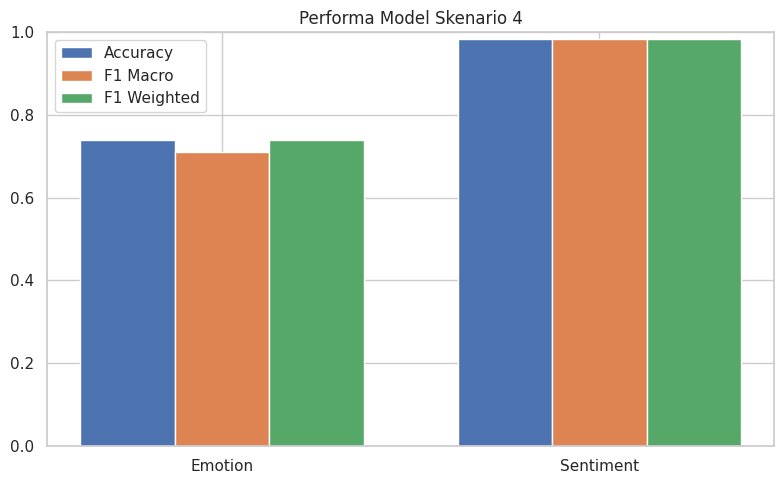

In [14]:
# tabel hasil
rows = []

for task_name, models in S4_RESULTS.items():

    for model_alias, result in models.items():

        row = {
            "Task": task_name,
            "Model": model_alias,
            "Accuracy": result["metrics"]["accuracy"],
            "F1 Macro": result["metrics"]["f1_macro"],
            "F1 Weighted": result["metrics"]["f1_weighted"],
            "Training Time (s)": result["metrics"]["train_time_s"],
            "Epoch": result["hyperparams"]["epochs"],
            "Batch Size": result["hyperparams"]["batch"],
            "Learning Rate": result["hyperparams"]["lr"],
            "Weight Decay": result["hyperparams"]["weight_decay"],
        }

        rows.append(row)

df_results_s4 = pd.DataFrame(rows)

display(df_results_s4)

plt.figure(figsize=(8,5))

x=np.arange(len(df_results_s4))
w=0.25

plt.bar(x-w,df_results_s4["Accuracy"],width=w,label="Accuracy")
plt.bar(x,df_results_s4["F1 Macro"],width=w,label="F1 Macro")
plt.bar(x+w,df_results_s4["F1 Weighted"],width=w,label="F1 Weighted")

plt.xticks(x,df_results_s4["Task"])
plt.ylim(0,1)
plt.legend()
plt.title("Performa Model Skenario 4")
plt.tight_layout()
plt.show()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

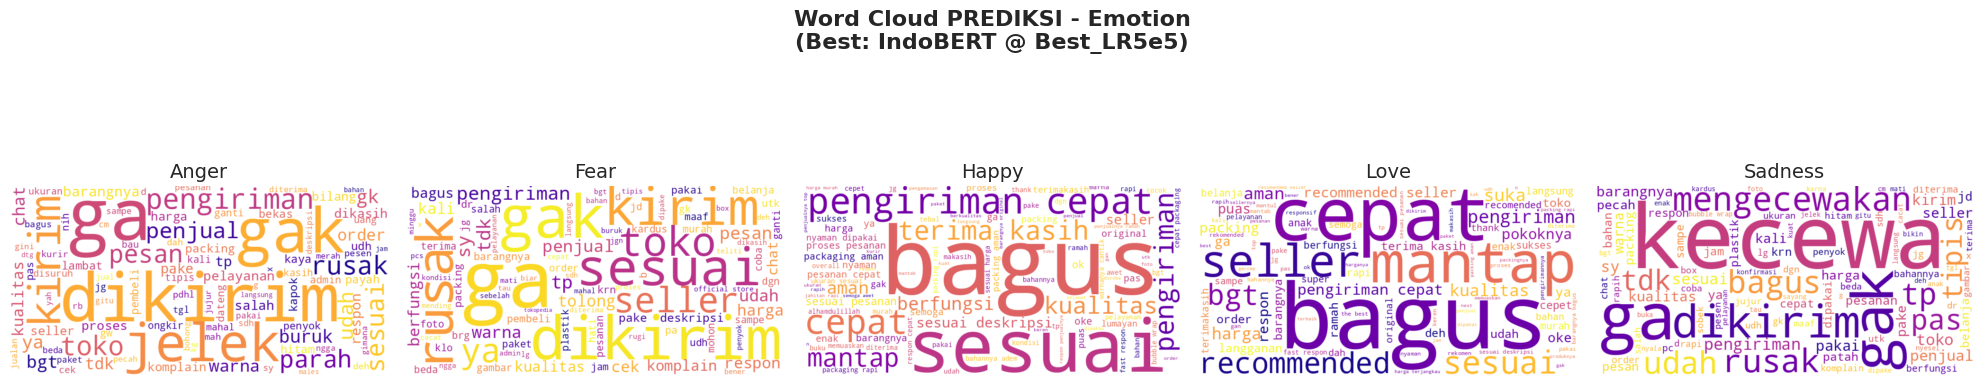

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

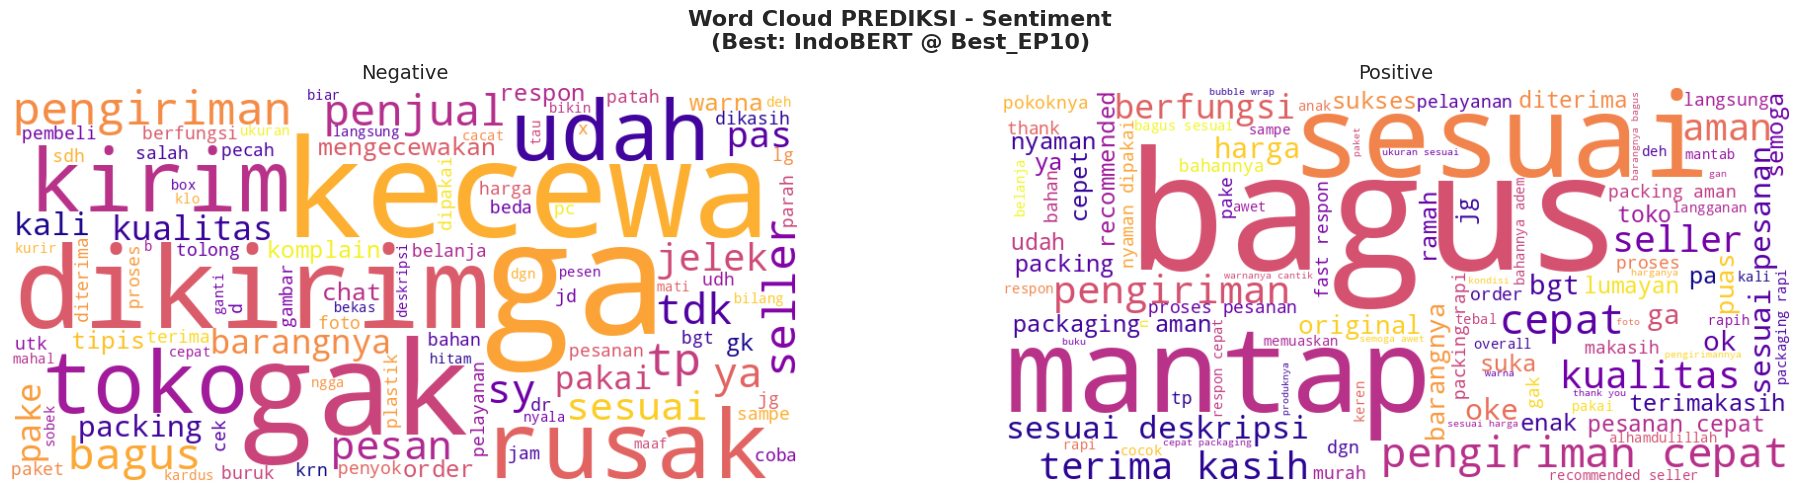

In [15]:
# 1. WORD CLOUD HASIL PREDIKSI MODEL 
pip("wordcloud", "nltk")
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer

nltk.download('stopwords', quiet=True)
indo_stopwords = set(stopwords.words('indonesian'))
custom_stopwords = {
    "yg", "nya", "di", "ke", "dari", "dan", "ini", "itu", "untuk", "dengan",
    "yang", "ada", "juga", "sudah", "buat", "karena", "kalo", "aku", "saya",
    "aja", "sama", "barang", "produk", "beli", "banget", "sih", "kok"
}
indo_stopwords = indo_stopwords.union(custom_stopwords)

for task_name, (text_col, label_col, label_names) in TASKS.items():
    best_dir = f"/kaggle/working/best_model_s4_{task_name}"

    if not os.path.exists(best_dir):
        print(f"Directory {best_dir} tidak ditemukan. Lewati task {task_name}.")
        continue

    test_texts = df_secondary[text_col].values
    test_labels = df_secondary[label_col].values

    tokenizer = AutoTokenizer.from_pretrained(best_dir)
    model = AutoModelForSequenceClassification.from_pretrained(best_dir).to(DEVICE)

    test_ds = build_hf_dataset(test_texts, test_labels, tokenizer)
    trainer = Trainer(model=model)

    preds_raw = trainer.predict(test_ds)
    preds_logits = preds_raw.predictions
    if isinstance(preds_logits, tuple):
        preds_logits = preds_logits[0]
    preds = np.argmax(preds_logits, axis=-1)

    df_pred = pd.DataFrame({
        "text": test_texts,
        "pred_label": [label_names[p] for p in preds]
    })

    fig, axes = plt.subplots(1, len(label_names), figsize=(20, 5))
    hp_label = BEST_MODEL_TRACKER[task_name]["hp_label"]

    fig.suptitle(
        f"Word Cloud PREDIKSI - {task_name}\n"
        f"(Best: {BEST_MODEL_TRACKER[task_name]['model_alias']} @ {hp_label})",
        fontsize=16,
        fontweight="bold"
    )

    if len(label_names) == 1:
        axes = [axes]

    for ax, cls in zip(axes, label_names):
        text_data = " ".join(df_pred[df_pred["pred_label"] == cls]["text"].tolist())

        if text_data.strip() == "":
            ax.set_title(f"{cls}\n(Tidak diprediksi)", fontsize=14, color='red')
            ax.axis("off")
            continue

        wc = WordCloud(width=800, height=400, background_color='white',
                       colormap='plasma', max_words=100,
                       stopwords=indo_stopwords).generate(text_data)

        ax.imshow(wc, interpolation='bilinear')
        ax.set_title(cls, fontsize=14)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

    del model, tokenizer, trainer, test_ds, df_pred
    free_memory()

Memproses Crosstab Prediksi...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

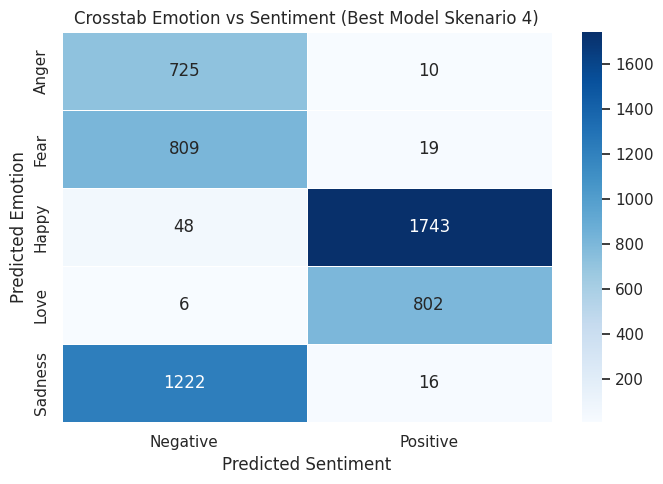

In [16]:
# crosstab
print("Memproses Crosstab Prediksi...")

preds_dict = {}

for task_name, (_, _, label_names) in TASKS.items():

    best_dir = f"/kaggle/working/best_model_s4_{task_name}"

    tokenizer = AutoTokenizer.from_pretrained(best_dir)
    model = AutoModelForSequenceClassification.from_pretrained(best_dir).to(DEVICE)

    trainer = Trainer(model=model)

    test_texts = df_secondary["text_clean"].values

    if task_name == "Emotion":
        test_labels = df_secondary["label_emotion"].values
    else:
        test_labels = df_secondary["label_sentiment"].values

    test_ds = build_hf_dataset(
        test_texts,
        test_labels,
        tokenizer
    )

    pred_raw = trainer.predict(test_ds)

    logits = pred_raw.predictions

    if isinstance(logits, tuple):
        logits = logits[0]

    pred_idx = np.argmax(logits, axis=1)

    preds_dict[task_name] = [
        label_names[i]
        for i in pred_idx
    ]

    del model, tokenizer, trainer, test_ds
    free_memory()

df_pred = pd.DataFrame({
    "Predicted Emotion": preds_dict["Emotion"],
    "Predicted Sentiment": preds_dict["Sentiment"]
})

cross_tab = pd.crosstab(
    df_pred["Predicted Emotion"],
    df_pred["Predicted Sentiment"]
)

plt.figure(figsize=(7,5))

sns.heatmap(
    cross_tab,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=.5
)

plt.title("Crosstab Emotion vs Sentiment (Best Model Skenario 4)")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Predicted Emotion")

plt.tight_layout()
plt.show()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

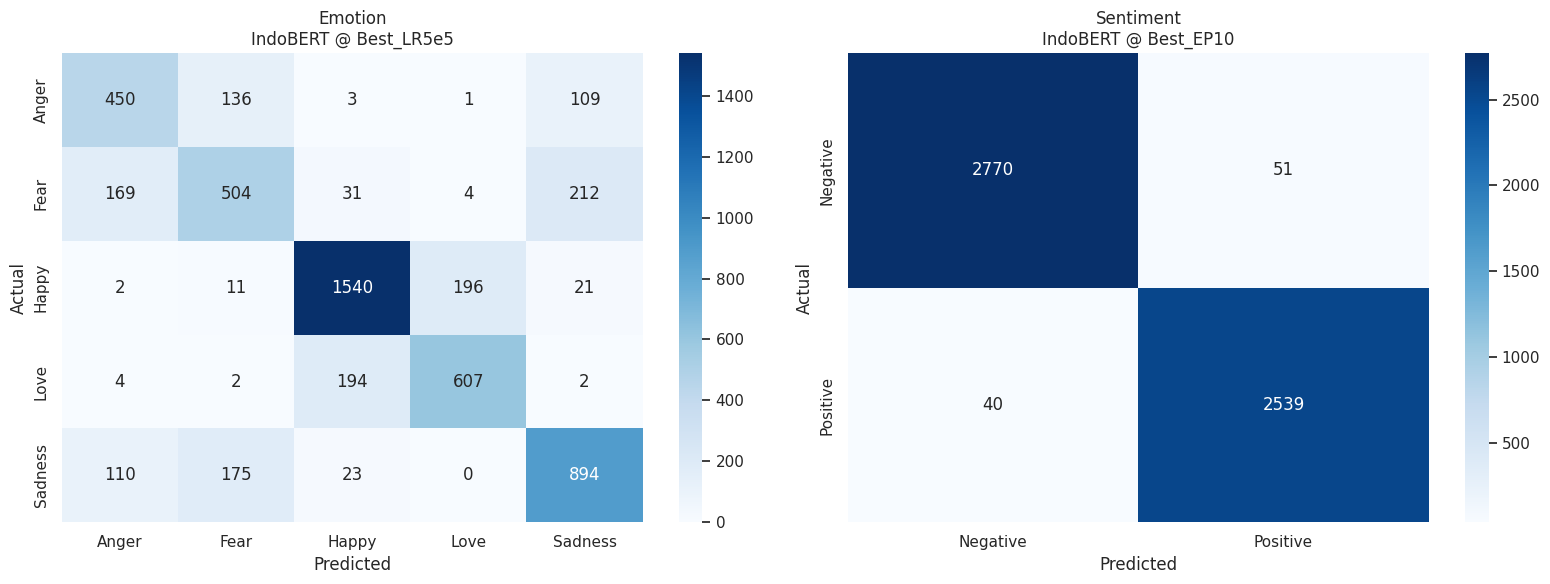

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16,6))

for idx,(task_name,(text_col,label_col,label_names)) in enumerate(TASKS.items()):

    best_dir=f"/kaggle/working/best_model_s4_{task_name}"

    tokenizer=AutoTokenizer.from_pretrained(best_dir)
    model=AutoModelForSequenceClassification.from_pretrained(best_dir).to(DEVICE)

    trainer=Trainer(model=model)

    test_texts=df_secondary[text_col].values
    test_labels=df_secondary[label_col].values

    test_ds=build_hf_dataset(
        test_texts,
        test_labels,
        tokenizer
    )

    pred_raw=trainer.predict(test_ds)

    logits=pred_raw.predictions

    if isinstance(logits,tuple):
        logits=logits[0]

    preds=np.argmax(logits,axis=-1)

    cm=confusion_matrix(test_labels,preds)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=label_names,
        yticklabels=label_names,
        ax=axes[idx]
    )

    hp_label=BEST_MODEL_TRACKER[task_name]["hp_label"]

    axes[idx].set_title(
        f"{task_name}\n{BEST_MODEL_TRACKER[task_name]['model_alias']} @ {hp_label}"
    )

    axes[idx].set_xlabel("Predicted")
    axes[idx].set_ylabel("Actual")

    del model,tokenizer,trainer,test_ds
    free_memory()

plt.tight_layout()
plt.show()